In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data preparation

In [3]:
df = pd.read_csv("data\\Personality_Syncora_Synthetic.csv")

In [5]:
round(df.describe())

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0
mean,4.0,0.0,4.0,3.0,0.0,6.0,4.0,0.0
std,3.0,0.0,3.0,2.0,0.0,4.0,3.0,0.0
min,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0
25%,2.0,0.0,2.0,1.0,0.0,3.0,1.0,0.0
50%,4.0,0.0,4.0,3.0,0.0,5.0,3.0,0.0
75%,7.0,1.0,6.0,5.0,1.0,10.0,6.0,1.0
max,12.0,1.0,11.0,8.0,1.0,16.0,11.0,1.0


- 'Time_spent_Alone': from -1 to 12,
-  'Stage_fear': boolean, 
- 'Social_event_attendance': -1 to 11,
- 'Going_outside': from -1 to 8, 
- 'Drained_after_socializing': boolean, 
- 'Friends_circle_size': -1 to 16,
- 'Post_frequency': -1 to 11, 
- 'Personality': boolean

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.columns

Index(['time_spent_alone', 'stage_fear', 'social_event_attendance',
       'going_outside', 'drained_after_socializing', 'friends_circle_size',
       'post_frequency', 'personality'],
      dtype='object')

## Exploratory Data Analysis (EDA)

In [33]:
print(f"Extroverts: {(df['personality'] == 0).sum()}\nIntroverts: {(df['personality'] == 1).sum()}")

Extroverts: 2597
Introverts: 2401


In [18]:
df[(df==-1)].sum()

time_spent_alone            -61.0
stage_fear                    0.0
social_event_attendance     -26.0
going_outside                -7.0
drained_after_socializing     0.0
friends_circle_size         -20.0
post_frequency              -39.0
personality                   0.0
dtype: float64

In [25]:
print(f'Missing values: {df.isnull().sum()}')

Missing values: time_spent_alone             0
stage_fear                   0
social_event_attendance      0
going_outside                0
drained_after_socializing    0
friends_circle_size          0
post_frequency               0
personality                  0
dtype: int64


In [ ]:
print(f'\nUnique values count per column: \n{df.nunique()}')
print(f'\nNumber of negative value: \n{(df<0).sum()}') # errors? 


Unique values count per column: 
time_spent_alone             14
stage_fear                    2
social_event_attendance      13
going_outside                10
drained_after_socializing     2
friends_circle_size          18
post_frequency               13
personality                   2
dtype: int64

Number of negative value: 
time_spent_alone             61
stage_fear                    0
social_event_attendance      26
going_outside                 7
drained_after_socializing     0
friends_circle_size          20
post_frequency               39
personality                   0
dtype: int64


Distribution of all features:


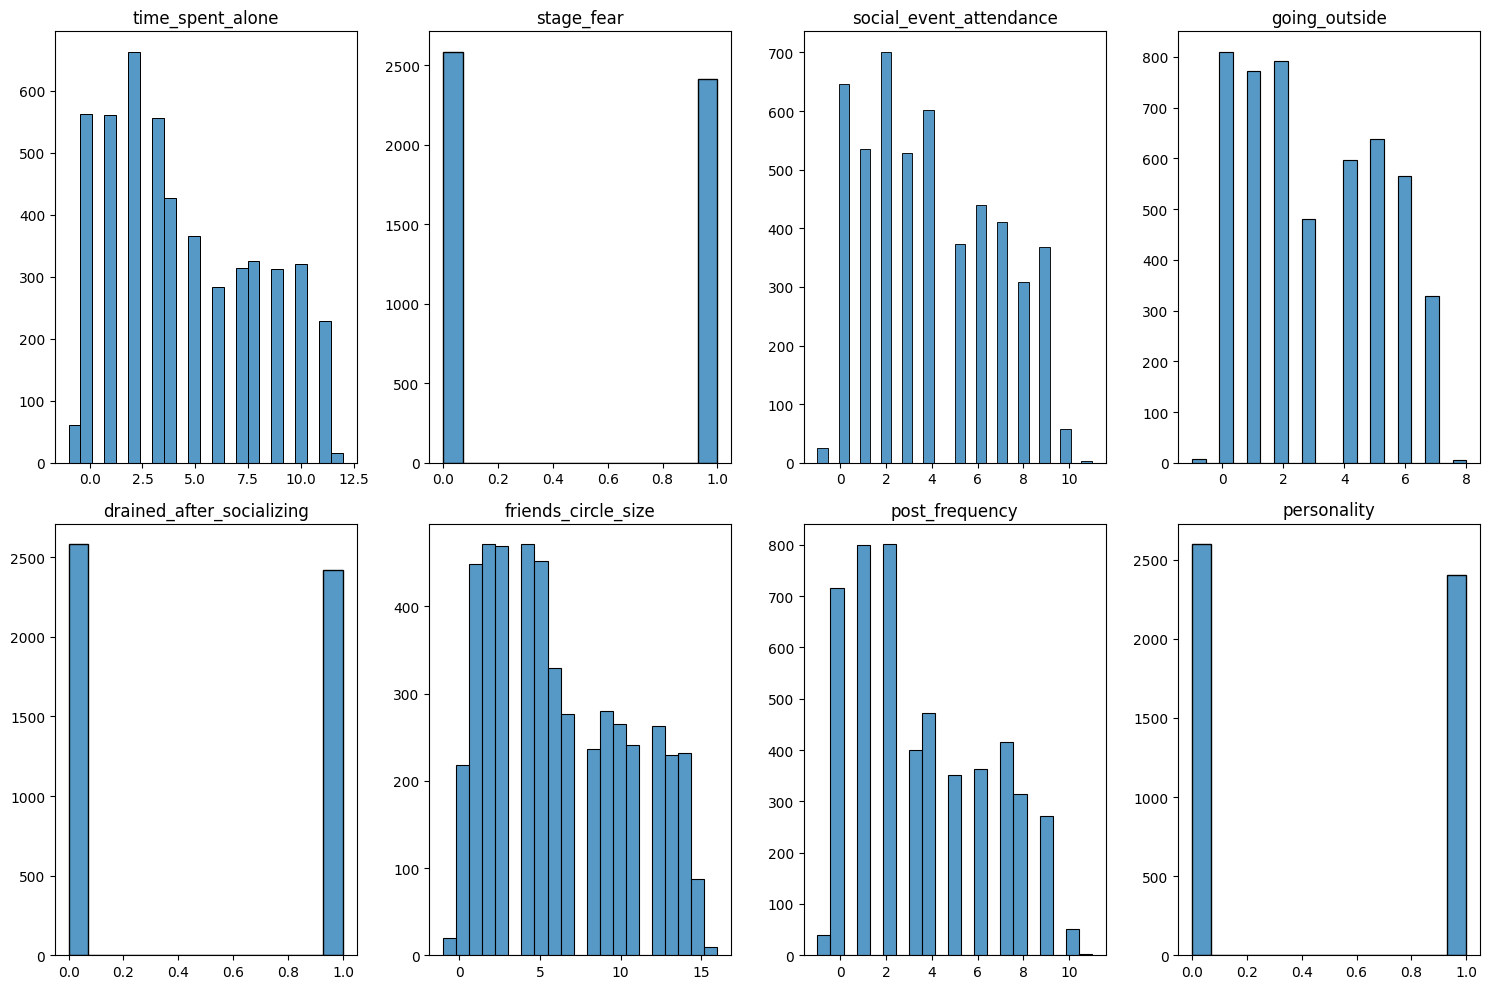

In [29]:
print("Distribution of all features:")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))
axes = axes.flatten()
features_to_plot =  df.columns.values
for i, col in enumerate(features_to_plot):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

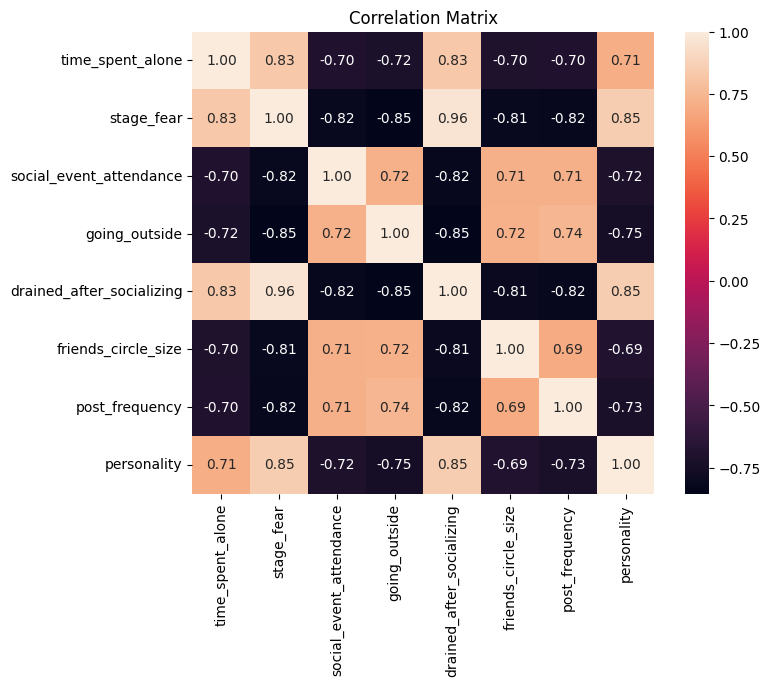

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()